In [36]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ── SparkSession (this is from the example in the project explanation - idk how we did it otherwise) ─
spark = SparkSession.builder \
    .appName("BeehiveExploration") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

In [33]:
df = spark.read.csv("all_data_updated.csv", header=True, inferSchema=True)
pdf = df.toPandas()
CONTINOUS_COLS = [
    "hive temp", "hive humidity", "hive pressure",
    "weather temp", "weather humidity", "weather pressure",
    "wind speed", "gust speed", "cloud coverage",
    "rain", "lat", "long", "frames", "time"
]

CATEGORICAL_COLS = [
    "device", "hive number", "weatherID",
    "queen presence", "queen acceptance",
    "queen status", "target"
]

In [4]:
# 3A

total_rows = df.count()
total_columns = len(df.columns)

print(f"Total observations (rows): {total_rows:,}")
print(f"Total columns: {total_columns}")

Total observations (rows): 1,275
Total columns: 23


In [5]:
# 3B

# Print schema
print("=" * 60)
print("SCHEMA")
print("=" * 60)
df.printSchema()

SCHEMA
root
 |-- device: integer (nullable = true)
 |-- hive number: integer (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- hive temp: double (nullable = true)
 |-- hive humidity: double (nullable = true)
 |-- hive pressure: double (nullable = true)
 |-- weather temp: double (nullable = true)
 |-- weather humidity: integer (nullable = true)
 |-- weather pressure: integer (nullable = true)
 |-- wind speed: double (nullable = true)
 |-- gust speed: double (nullable = true)
 |-- weatherID: integer (nullable = true)
 |-- cloud coverage: integer (nullable = true)
 |-- rain: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- file name: string (nullable = true)
 |-- queen presence: integer (nullable = true)
 |-- queen acceptance: integer (nullable = true)
 |-- frames: integer (nullable = true)
 |-- target: integer (nullable = true)
 |-- time: double (nullable = true)
 |-- queen status: integer (nullable = true)



In [16]:
# Describe statistics
print("=" * 60)
print("Description Statistics")
print("=" * 60)
df.select([F.col(f"`{c}`") for c in CONTINOUS_COLS]).describe().show(truncate=False)

Description Statistics
+-------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+----+-----------------+-------------------+-----------------+-------------------+
|summary|hive temp         |hive humidity     |hive pressure    |weather temp     |weather humidity  |weather pressure  |wind speed        |gust speed        |cloud coverage    |rain|lat              |long               |frames           |time               |
+-------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+----+-----------------+-------------------+-----------------+-------------------+
|count  |1275              |1275              |1275             |1271             |1275              |1275              |1271              |281               |1275              |1275|1271          

In [7]:
print("=" * 60)
print("Quantiles")
print("=" * 60)
quantile_aggs = []
for c in CONTINOUS_COLS:
    quantile_aggs += [
        F.expr(f"percentile_approx(`{c}`, 0.25)").alias(f"{c}_Q1"),
        F.expr(f"percentile_approx(`{c}`, 0.50)").alias(f"{c}_median"),
        F.expr(f"percentile_approx(`{c}`, 0.75)").alias(f"{c}_Q3"),
    ]
df.agg(*quantile_aggs).show(vertical=True, truncate=False)

Quantiles
-RECORD 0--------------------------
 hive temp_Q1            | 22.45   
 hive temp_median        | 27.91   
 hive temp_Q3            | 33.09   
 hive humidity_Q1        | 32.24   
 hive humidity_median    | 42.18   
 hive humidity_Q3        | 55.0    
 hive pressure_Q1        | 1007.37 
 hive pressure_median    | 1009.17 
 hive pressure_Q3        | 1010.71 
 weather temp_Q1         | 15.48   
 weather temp_median     | 19.28   
 weather temp_Q3         | 24.85   
 weather humidity_Q1     | 51      
 weather humidity_median | 66      
 weather humidity_Q3     | 78      
 weather pressure_Q1     | 1013    
 weather pressure_median | 1014    
 weather pressure_Q3     | 1016    
 wind speed_Q1           | 2.06    
 wind speed_median       | 3.6     
 wind speed_Q3           | 5.66    
 gust speed_Q1           | 1.34    
 gust speed_median       | 2.68    
 gust speed_Q3           | 7.6     
 cloud coverage_Q1       | 0       
 cloud coverage_median   | 20      
 cloud coverage_Q3

In [8]:
print("=" * 60)
print("Categorical Column Distribution")
print("=" * 60)
for col in CATEGORICAL_COLS:
    print(f"\n--- {col} ---")
    df.groupBy(col) \
      .agg(
          F.count("*").alias("count"),
          F.round(F.count("*") / total_rows * 100, 2).alias("pct_%")
      ) \
      .orderBy(col) \
      .show(truncate=False)



Categorical Column Distribution

--- device ---
+------+-----+-----+
|device|count|pct_%|
+------+-----+-----+
|1     |568  |44.55|
|2     |707  |55.45|
+------+-----+-----+


--- hive number ---
+-----------+-----+-----+
|hive number|count|pct_%|
+-----------+-----+-----+
|1          |518  |40.63|
|3          |189  |14.82|
|4          |471  |36.94|
|5          |97   |7.61 |
+-----------+-----+-----+


--- weatherID ---
+---------+-----+-----+
|weatherID|count|pct_%|
+---------+-----+-----+
|0        |4    |0.31 |
|701      |4    |0.31 |
|711      |27   |2.12 |
|721      |8    |0.63 |
|800      |531  |41.65|
|801      |336  |26.35|
|802      |88   |6.9  |
|803      |164  |12.86|
|804      |113  |8.86 |
+---------+-----+-----+


--- queen presence ---
+--------------+-----+-----+
|queen presence|count|pct_%|
+--------------+-----+-----+
|0             |158  |12.39|
|1             |1117 |87.61|
+--------------+-----+-----+


--- queen acceptance ---
+----------------+-----+-----+
|queen 

In [9]:
print("=" * 60)
print("Unique Value Counts")
print("=" * 60)
for col in CATEGORICAL_COLS:
    n = df.select(F.col(f"`{col}`")).distinct().count()
    print(f"  {col}: {n} unique values")

Unique Value Counts
  device: 2 unique values
  hive number: 4 unique values
  weatherID: 9 unique values
  queen presence: 2 unique values
  queen acceptance: 3 unique values
  queen status: 4 unique values
  target: 6 unique values


In [10]:
# 3C

print("=" * 60)
print("Null Value Counts Per Column")
print("=" * 60)
for c in df.columns:
    null_count = df.filter(F.col(f"`{c}`").isNull()).count()
    null_pct = round(null_count / total_rows * 100, 2)
    print(f"{c:30s}  nulls: {null_count:4d}  ({null_pct}%)")


print("=" * 60)
print("Duplicate Row Check")
print("=" * 60)
distinct_rows = df.distinct().count()
duplicate_count = total_rows - distinct_rows

print(f"Total rows:     {total_rows:,}")
print(f"Distinct rows:  {distinct_rows:,}")
print(f"Duplicate rows: {duplicate_count:,}")

Null Value Counts Per Column
device                          nulls:    0  (0.0%)
hive number                     nulls:    0  (0.0%)
date                            nulls:    0  (0.0%)
hive temp                       nulls:    0  (0.0%)
hive humidity                   nulls:    0  (0.0%)
hive pressure                   nulls:    0  (0.0%)
weather temp                    nulls:    4  (0.31%)
weather humidity                nulls:    0  (0.0%)
weather pressure                nulls:    0  (0.0%)
wind speed                      nulls:    4  (0.31%)
gust speed                      nulls:  994  (77.96%)
weatherID                       nulls:    0  (0.0%)
cloud coverage                  nulls:    0  (0.0%)
rain                            nulls:    0  (0.0%)
lat                             nulls:    4  (0.31%)
long                            nulls:    4  (0.31%)
file name                       nulls:    0  (0.0%)
queen presence                  nulls:    0  (0.0%)
queen acceptance             

## Data Visualization Overview

The following visualizations help uncover patterns, correlations, and potential indicators of hive health, particularly in relation to whether a queen is present, accepted, or absent.

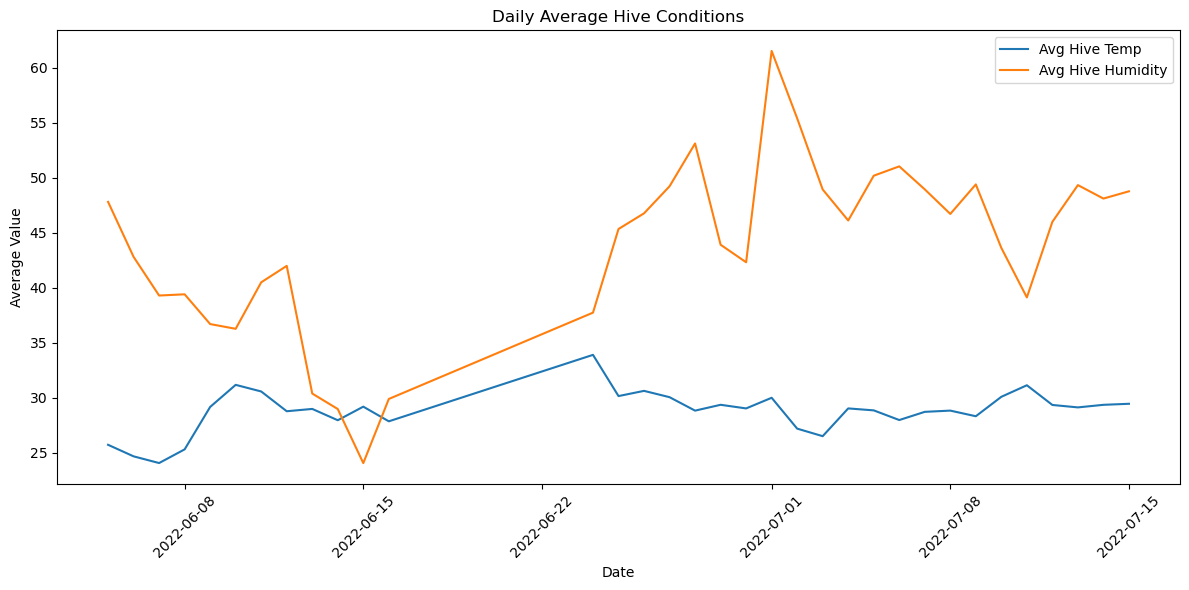

In [46]:
pdf['date'] = pd.to_datetime(pdf['date'])

# Convert timestamp → just date
pdf['day'] = pdf['date'].dt.date

# Group by day and take mean
daily_df = pdf.groupby('day')[['hive temp', 'hive humidity']].mean().reset_index()

plt.figure(figsize=(12,6))

plt.plot(daily_df['day'], daily_df['hive temp'], label='Avg Hive Temp')
plt.plot(daily_df['day'], daily_df['hive humidity'], label='Avg Hive Humidity')

plt.title('Daily Average Hive Conditions')
plt.xlabel('Date')
plt.ylabel('Average Value')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

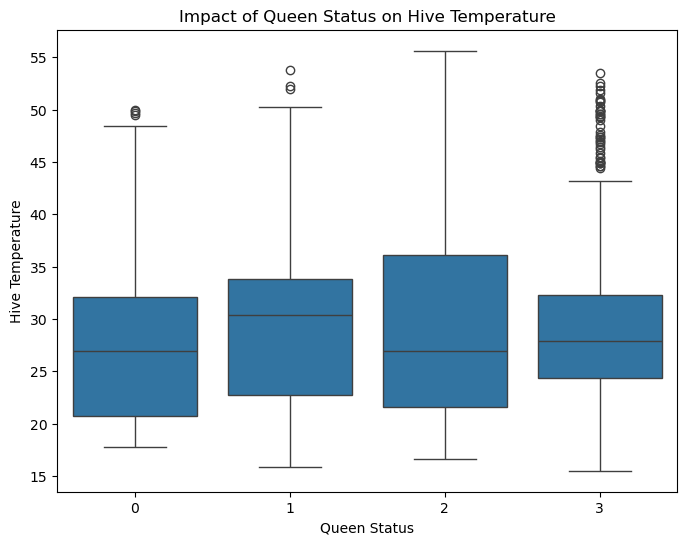

In [43]:
plt.figure(figsize=(8,6))

sns.boxplot(x='queen status', y='hive temp', data=pdf)

plt.title('Impact of Queen Status on Hive Temperature')
plt.xlabel('Queen Status')
plt.ylabel('Hive Temperature')

plt.show()

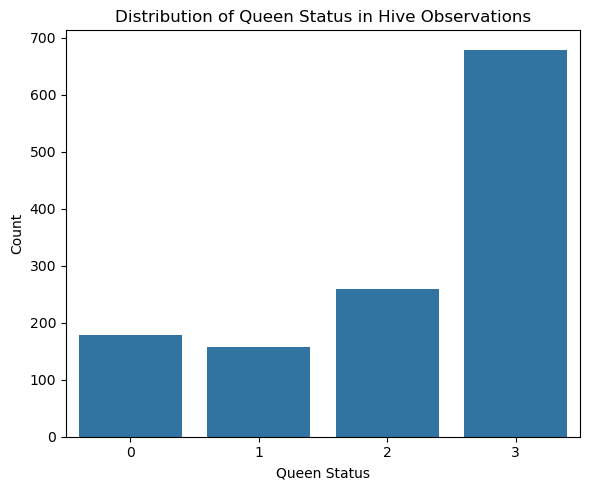

In [42]:
plt.figure(figsize=(6,5))

sns.countplot(x='queen status', data=pdf)

plt.title('Distribution of Queen Status in Hive Observations')
plt.xlabel('Queen Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

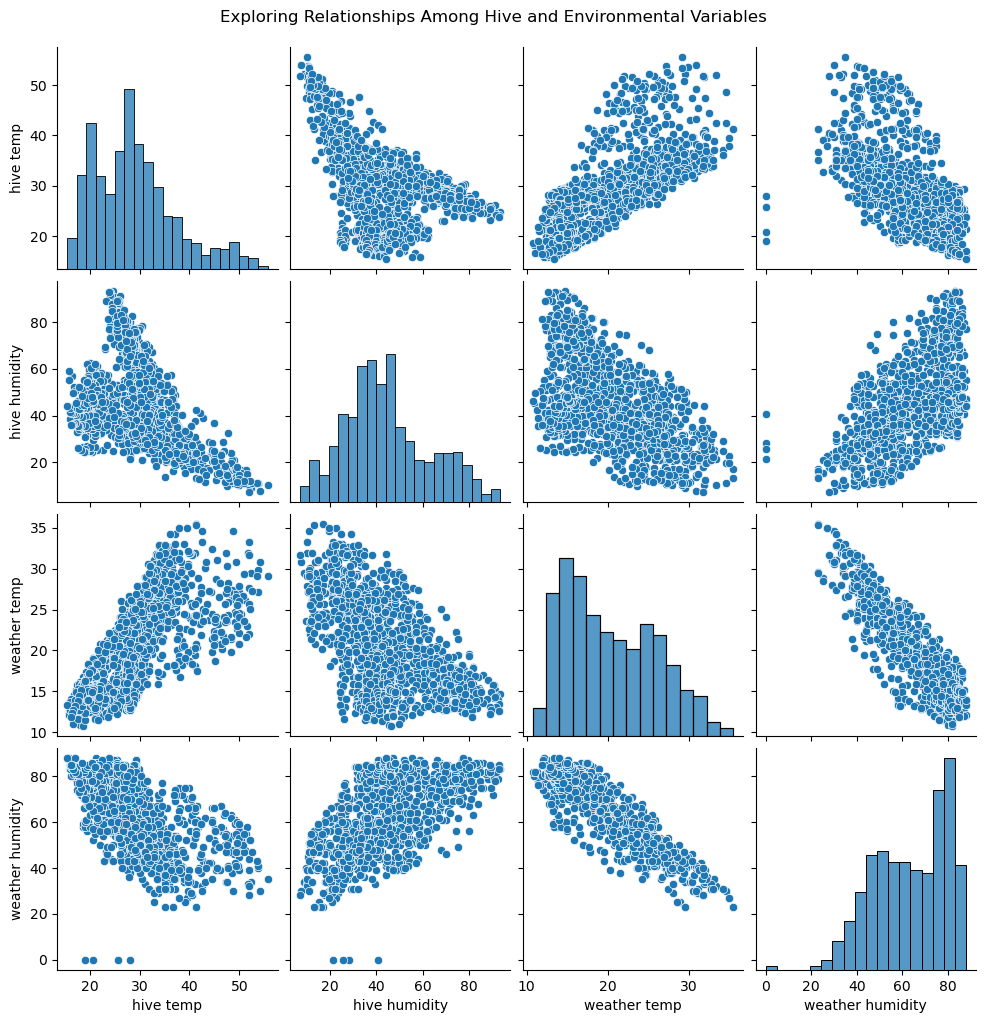

In [40]:
sns.pairplot(pdf[['hive temp', 'hive humidity', 'weather temp', 'weather humidity']])

plt.suptitle('Exploring Relationships Among Hive and Environmental Variables', y=1.02)

plt.show()

In [47]:
import requests

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
sparkdf = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
sparkdf['maxMemory_GB'] = (sparkdf['maxMemory'] / (1024**3)).round(2)
sparkdf

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,1099746508,0,True,1.02
